# How to start:

1) Download repo:
```bash
git clone https://github.com/kandinskylab/kandinsky-5.git
```

2) Go to directory:
```bash
cd kandinsky-5
```

3) Create enviroment and install dependencies:
```bash
conda create --prefix ./conda_env python=3.11 ipykernel -y
conda activate ./conda_env 
pip install -r requirements.txt  
```

4) Download model:
```bash
python download_models.py --models kandinskylab/Kandinsky-5.0-T2V-Lite-sft-5s 
```

if you want faster generation you can donwload distilled model

```bash
python download_models.py --models kandinskylab/Kandinsky-5.0-T2V-Lite-distilled16steps-5s
```

5) Add this ```.ipynb``` file to the ```kandinsky-5``` folder and enjoy

# Baseline model

### Lite (2 billion parameters) model


In [1]:
import gc
import os
import time 
import torch

from kandinsky import get_video_pipeline
from IPython.display import Video

from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()

In [2]:
pipe = get_video_pipeline(
    device_map={"dit": "cuda:0", "vae": "cuda:0", "text_embedder": "cuda:0"},
    conf_path="./configs/k5_lite_t2v_5s_sft_sd.yaml", # use "./configs/k5_lite_t2v_5s_distil_sd.yaml" if you want distilled version
    mode='t2v',
)

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [3]:
def print_model_memory(model, name):
    if name == None:
        name = "Model"
    model_bytes = sum(
        p.nelement() * p.element_size() for p in model.parameters()
    ) + sum(b.nelement() * b.element_size() for b in model.buffers())
    
    print(f"{name} uses {model_bytes / (1024 ** 3):.2f} GB")

print_model_memory(pipe.dit, "DiT")
print_model_memory(pipe.text_embedder.embedder.model, "Qwen Text Embedder")
print_model_memory(pipe.text_embedder.clip_embedder.model, "CLIP Text Embedder")
print_model_memory(pipe.vae, "VAE")

torch.cuda.empty_cache()
print(f"Total CUDA memory allocated: {torch.cuda.memory_allocated() / (1024 ** 3):.2f} GB")

DiT uses 4.26 GB
Qwen Text Embedder uses 15.45 GB
CLIP Text Embedder uses 0.46 GB
VAE uses 0.46 GB
Total CUDA memory allocated: 20.71 GB


In [4]:
torch.cuda.reset_peak_memory_stats()
start_time = time.perf_counter()

out = pipe(
    "A cat in a red hat and green boots", 
    time_length=5, width=768, height=512, 
    save_path='./test01.mp4',
    seed=42
)

time_elapsed = time.perf_counter() - start_time
peak_bytes = torch.cuda.max_memory_allocated()
peak_megabytes = peak_bytes / (1024 ** 3)

print(f"Maximum CUDA memory used: {peak_megabytes:.2f} GB, Time elapsed: {time_elapsed:.2f} s")

Video('./test01.mp4')

100%|██████████| 50/50 [03:44<00:00,  4.49s/it]
/home/jovyan/maria/files/eccv/kandinsky-5/conda_env/lib/python3.11/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


Maximum CUDA memory used: 39.24 GB, Time elapsed: 268.67 s


In [5]:
del pipe, out
gc.collect()
torch.cuda.empty_cache()

# Offloading

Example how it works in generation:

```python
if offload:
    dit = dit.to('cpu', non_blocking=True)
torch.cuda.empty_cache()

if offload:
    vae = vae.to(vae_device, non_blocking=True)
```

In [6]:
pipe = get_video_pipeline(
    device_map={"dit": "cuda:0", "vae": "cuda:0", "text_embedder": "cuda:0"},
    conf_path="./configs/k5_lite_t2v_5s_sft_sd.yaml",
    mode='t2v',
    offload=True,
)

torch.cuda.empty_cache()
print(f"Total CUDA memory allocated: {torch.cuda.memory_allocated() / (1024 ** 3):.2f} GB")

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Total CUDA memory allocated: 0.03 GB


In [7]:
torch.cuda.reset_peak_memory_stats()
start_time = time.perf_counter()

out = pipe(
    "A cat in a red hat and green boots", 
    time_length=5, width=768, height=512, 
    save_path='./test02.mp4',
    seed=42
)

time_elapsed = time.perf_counter() - start_time
peak_bytes = torch.cuda.max_memory_allocated()
peak_megabytes = peak_bytes / (1024 ** 3)

print(f"Maximum CUDA memory used: {peak_megabytes:.2f} GB, Time elapsed: {time_elapsed:.2f} s")

Video('./test02.mp4')

100%|██████████| 50/50 [03:16<00:00,  3.93s/it]


Maximum CUDA memory used: 19.01 GB, Time elapsed: 229.82 s


In [8]:
del pipe, out
gc.collect()
torch.cuda.empty_cache()

# Quantized Text embedder

How to initialize quantized model:

```python
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    BitsAndBytesConfig
)

quantization_config = None
if quantized_qwen:
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"
    )

self.model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    conf.checkpoint_path,
    dtype=torch.bfloat16,
    device_map=device,
    quantization_config=quantization_config
)
```

In [9]:
pipe = get_video_pipeline(
    device_map={"dit": "cuda:0", "vae": "cuda:0", "text_embedder": "cuda:0"},
    conf_path="./configs/k5_lite_t2v_5s_sft_sd.yaml",
    mode='t2v',
    offload=True,
    quantized_qwen=True,
)

torch.cuda.empty_cache()
print_model_memory(pipe.dit, "DiT")
print_model_memory(pipe.text_embedder.embedder.model, "Qwen Text Embedder")
print_model_memory(pipe.text_embedder.clip_embedder.model, "CLIP Text Embedder")
print_model_memory(pipe.vae, "VAE")
print(f"Total CUDA memory allocated: {torch.cuda.memory_allocated() / (1024 ** 3):.2f} GB")

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

DiT uses 4.26 GB
Qwen Text Embedder uses 5.39 GB
CLIP Text Embedder uses 0.46 GB
VAE uses 0.46 GB
Total CUDA memory allocated: 0.03 GB


In [10]:
torch.cuda.reset_peak_memory_stats()
start_time = time.perf_counter()

out = pipe(
    "A cat in a red hat and green boots", 
    time_length=5, width=768, height=512, 
    save_path='./test03.mp4',
    seed=42
)

time_elapsed = time.perf_counter() - start_time
peak_bytes = torch.cuda.max_memory_allocated()
peak_megabytes = peak_bytes / (1024 ** 3)

print(f"Maximum CUDA memory used: {peak_megabytes:.2f} GB, Time elapsed: {time_elapsed:.2f} s")

Video('./test03.mp4')

100%|██████████| 50/50 [03:16<00:00,  3.92s/it]
/home/jovyan/maria/files/eccv/kandinsky-5/conda_env/lib/python3.11/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


Maximum CUDA memory used: 19.01 GB, Time elapsed: 231.00 s


In [11]:
del pipe, out
gc.collect()
torch.cuda.empty_cache()

# MagCache


<span style="font-size: 2em;">$r_t = v_{\theta}(x_t, t) − x_t$ - residuals</span>

<span style="font-size: 2em;">$\gamma_t = \text{mean}\left(\frac{\|r_t\|_2}{\|r_{t−1}\|_2}\right)$ - per-step residuals magnitude ratio</span>
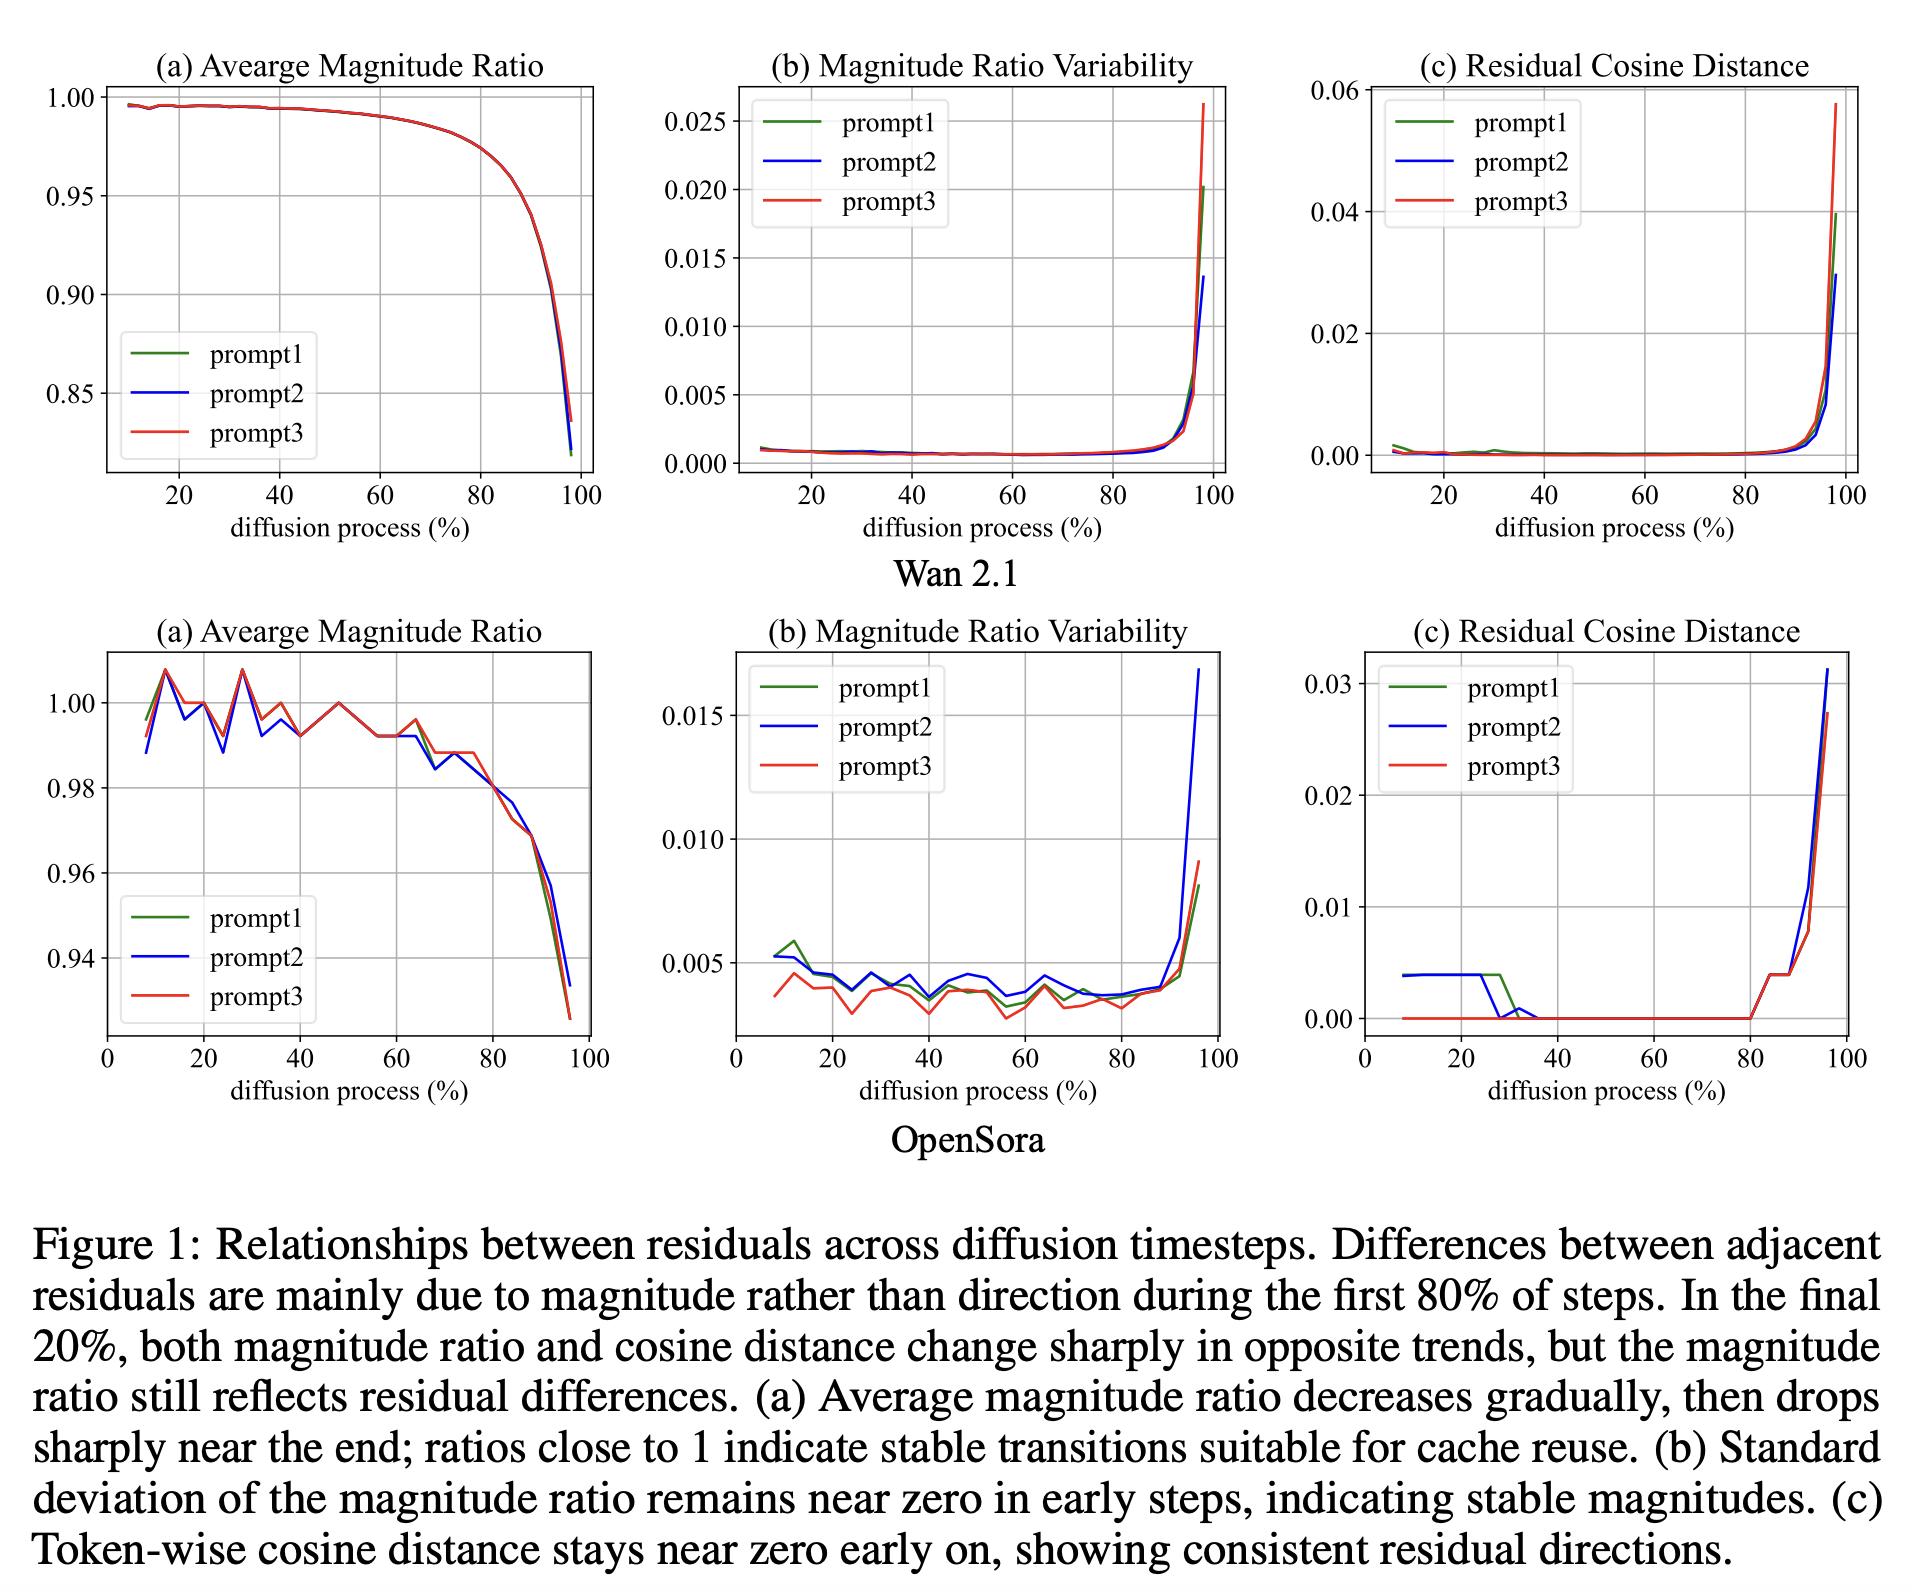

<span style="font-size: 2em;">$\epsilon_{skip}(t, t' ) = 1 − \prod^t_{i=t'+1} {\gamma_i}$ - skip error from $t'$ to $t$</span>
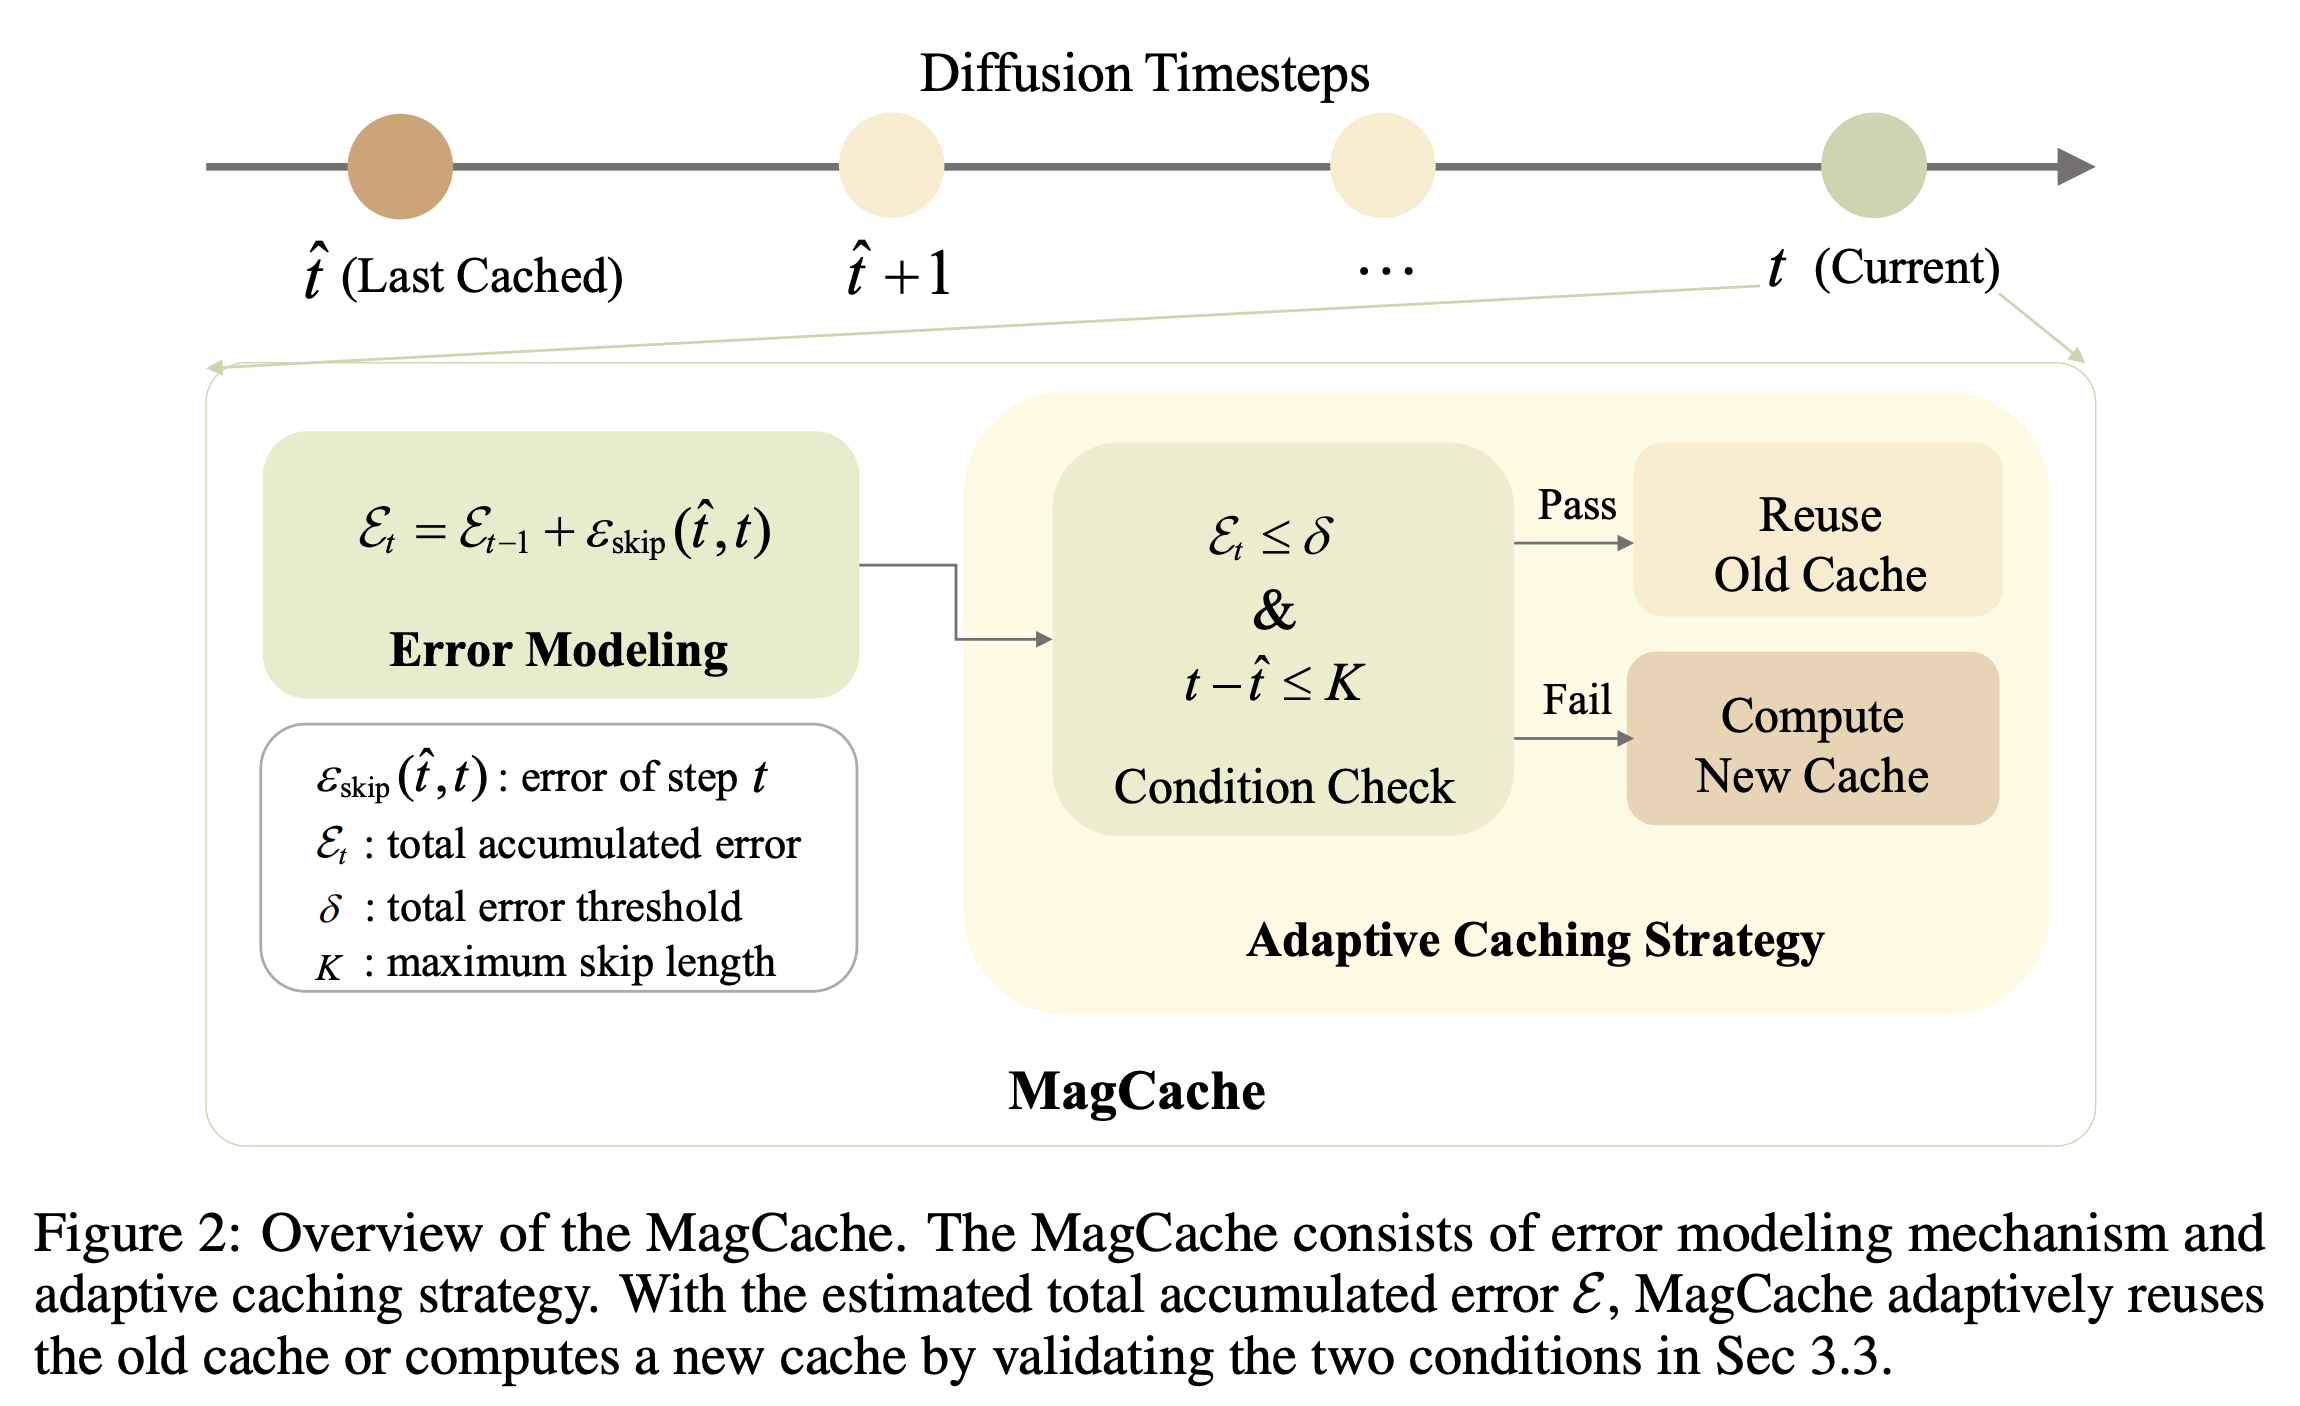

<span style="font-size: 2em;"> **Magnitude-aware Cache (MagCache)**: If accumulated error is bigger that predefined value then recompute cache, else reuse residual from previous step</span>

In [12]:
pipe = get_video_pipeline(
    device_map={"dit": "cuda:0", "vae": "cuda:0", "text_embedder": "cuda:0"},
    conf_path="./configs/k5_lite_t2v_5s_sft_sd.yaml",
    mode='t2v',
    offload=True,
    quantized_qwen=True,
    magcache=True
)

torch.cuda.empty_cache()
print(f"Total CUDA memory allocated: {torch.cuda.memory_allocated() / (1024 ** 3):.2f} GB")

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

using Magcache
Total CUDA memory allocated: 0.03 GB


In [13]:
torch.cuda.reset_peak_memory_stats()
start_time = time.perf_counter()

out = pipe(
    "A cat in a red hat and green boots", 
    time_length=5, width=768, height=512, 
    save_path='./test04.mp4',
    seed=42
)

time_elapsed = time.perf_counter() - start_time
peak_bytes = torch.cuda.max_memory_allocated()
peak_megabytes = peak_bytes / (1024 ** 3)

print(f"Maximum CUDA memory used: {peak_megabytes:.2f} GB, Time elapsed: {time_elapsed:.2f} s")

Video('./test04.mp4')

100%|██████████| 50/50 [01:33<00:00,  1.87s/it]


Maximum CUDA memory used: 19.32 GB, Time elapsed: 121.87 s
